# Task 1
## Task 1.1

**Estado elegido: Alabama (`AL`, FIPS `01`).** Tiene 114 hospitales con datos de camas (más del mínimo de 50),
67 condados con mezcla de áreas metropolitanas (Birmingham, Huntsville, Mobile, Montgomery) y condados rurales
del *Black Belt*, y cabe completo en una sola zona UTM, lo que simplifica la medición de distancias.

### a. Carga de los cuatro archivos
Las dependencias están en `requirements.txt`. Para instalarlas (en un entorno virtual):

```bash
python -m venv .venv
.venv\Scripts\activate          # Windows  (Linux/Mac: source .venv/bin/activate)
pip install -r requirements.txt
```

In [1]:
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import shapely
import pyproj
from scipy import stats
from scipy.spatial import cKDTree
from matplotlib_scalebar.scalebar import ScaleBar

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

print("geopandas :", gpd.__version__)
print("shapely   :", shapely.__version__)
print("pandas    :", pd.__version__)
print("numpy     :", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("pyproj    :", pyproj.__version__)

geopandas : 1.2.0
shapely   : 2.1.2
pandas    : 3.0.6
numpy     : 2.5.3
matplotlib: 3.11.2
pyproj    : 3.8.0


In [2]:
# ---------------- Parámetros globales del análisis ----------------
STATE = "AL"              # código postal del estado (columna `estado` de hospitales)
STATE_FIPS = "01"         # código FIPS del estado (columna `cod_estado` de condados)
STATE_NAME = "Alabama"
CRS_PROJ = "EPSG:32616"   # WGS 84 / UTM zona 16N (metros) -> justificación en Task 1.1d
RADII_KM = [10, 25, 50]   # radios de buffer del Task 1.3
R_MAP = 25                # radio del mapa de cobertura y del MCLP

# Paleta (categórica en orden fijo; diverging azul<->rojo con gris neutro)
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NEUTRAL = "#f0efec"
TIPO_ES = {"GENERAL ACUTE CARE": "Cuidados agudos generales", "CRITICAL ACCESS": "Acceso crítico",
           "PSYCHIATRIC": "Psiquiátrico", "LONG TERM CARE": "Cuidados a largo plazo",
           "REHABILITATION": "Rehabilitación", "MILITARY": "Militar", "CHILDREN": "Infantil",
           "SPECIAL": "Especial", "WOMEN": "Mujeres", "CHRONIC DISEASE": "Enfermedad crónica", "OTHER": "Otro"}


def add_north_and_scale(ax, loc="lower left"):
    """Escala gráfica (las coordenadas están en metros) y flecha de norte."""
    ax.add_artist(ScaleBar(1, units="m", location=loc, box_alpha=0.8, length_fraction=0.25))
    ax.annotate("N", xy=(0.95, 0.95), xytext=(0.95, 0.85), xycoords="axes fraction",
                ha="center", va="center", fontsize=14, fontweight="bold",
                arrowprops=dict(facecolor="black", width=4, headwidth=12))

In [3]:
hosp_raw = gpd.read_file("hospitales_eeuu.geojson")
counties_raw = gpd.read_file("condados_eeuu.geojson")
states = gpd.read_file("estados_eeuu.geojson")
pop_raw = pd.read_csv("poblacion_condados.csv")

resumen = pd.DataFrame([
    {"archivo": name, "registros": len(df), "CRS": str(df.crs) if isinstance(df, gpd.GeoDataFrame) else "— (tabla)",
     "columnas": ", ".join(df.columns)}
    for name, df in [("hospitales_eeuu.geojson", hosp_raw), ("condados_eeuu.geojson", counties_raw),
                     ("poblacion_condados.csv", pop_raw), ("estados_eeuu.geojson", states)]])
with pd.option_context("display.max_colwidth", 200):
    display(resumen)

,archivo,registros,CRS,columnas
0,hospitales_eeuu.geojson,7154,EPSG:4326,"nombre, tipo, ciudad, estado, condado, fips_condado, camas_total, camas_icu, camas_licenciadas, ocupacion_total, ocupacion_icu, geometry"
1,condados_eeuu.geojson,3221,EPSG:4326,"fips, nombre, cod_estado, geometry"
2,poblacion_condados.csv,3246,— (tabla),"fips, condado, estado, lat, lon, poblacion"
3,estados_eeuu.geojson,51,EPSG:4326,"nombre, codigo, pais, geometry"


### b. Limpieza del dataset completo

1. **Población:** los FIPS ≥ 80000 son registros “Out of XX” (personas reportadas fuera de su condado de
   residencia), no condados reales; se eliminan. Luego `fips` se convierte a texto de 5 dígitos con ceros a la
   izquierda (`1001` → `"01001"`) para que sea compatible con `condados_eeuu.geojson`.
2. **Hospitales:** se reporta el porcentaje de `camas_total` nulo y se conservan solo los hospitales con camas.

In [4]:
n_fake = (pop_raw["fips"] >= 80000).sum()
pop = pop_raw[pop_raw["fips"] < 80000].copy()
pop["fips"] = pop["fips"].astype(int).astype(str).str.zfill(5)
print(f"Población: {len(pop_raw)} registros -> {len(pop)} (eliminados {n_fake} con FIPS >= 80000)")
print(f"  ¿Todos los FIPS tienen 5 dígitos? {pop['fips'].str.len().eq(5).all()} | ejemplo: {pop['fips'].iloc[0]}")
print(f"  Población nula restante: {pop['poblacion'].isna().sum()}")

pct_null = 100 * hosp_raw["camas_total"].isna().mean()
pct_null_st = 100 * hosp_raw.loc[hosp_raw["estado"] == STATE, "camas_total"].isna().mean()
hosp = hosp_raw[hosp_raw["camas_total"].notna()].copy()
print(f"\nHospitales con camas_total nulo: {hosp_raw['camas_total'].isna().sum()} de {len(hosp_raw)} "
      f"= {pct_null:.2f} % (en {STATE_NAME}: {pct_null_st:.2f} %)")
print(f"Hospitales con datos de camas (EE.UU.): {len(hosp)}")
print(f"Hospitales en {STATE_NAME}: {(hosp_raw.estado == STATE).sum()} antes -> {(hosp.estado == STATE).sum()} "
      "después de la limpieza")

Población: 3246 registros -> 3144 (eliminados 102 con FIPS >= 80000)
  ¿Todos los FIPS tienen 5 dígitos? True | ejemplo: 01001
  Población nula restante: 0

Hospitales con camas_total nulo: 1090 de 7154 = 15.24 % (en Alabama: 12.31 %)
Hospitales con datos de camas (EE.UU.): 6064
Hospitales en Alabama: 130 antes -> 114 después de la limpieza


### c. Filtro por estado y unión población–geometría

In [5]:
hosp_st = hosp[hosp["estado"] == STATE].reset_index(drop=True)
cty_geo = counties_raw[counties_raw["cod_estado"] == STATE_FIPS]
pop_st = pop[pop["fips"].str[:2] == STATE_FIPS]
state_geo = states[states["codigo"] == STATE]

# unión 1:1 por la llave FIPS
cty = cty_geo.merge(pop_st[["fips", "poblacion"]], on="fips", how="left", validate="1:1").reset_index(drop=True)
print(f"Condados con geometría : {len(cty_geo)}")
print(f"Condados con población : {len(pop_st)}")
print(f"Condados unidos        : {cty['poblacion'].notna().sum()}  -> ¿coinciden? "
      f"{len(cty_geo) == len(pop_st) == cty['poblacion'].notna().sum()}")
print(f"Población total de {STATE_NAME}: {cty['poblacion'].sum():,.0f}")

# verificación espacial: ¿todos los hospitales caen dentro del límite estatal?
inside_state = hosp_st.within(state_geo.geometry.iloc[0])
print(f"\nHospitales del estado: {len(hosp_st)} | dentro del polígono estatal: {inside_state.sum()}")
print(hosp_st["tipo"].value_counts().rename(index=TIPO_ES).to_string())

Condados con geometría : 67
Condados con población : 67
Condados unidos        : 67  -> ¿coinciden? True
Población total de Alabama: 4,903,185

Hospitales del estado: 114 | dentro del polígono estatal: 113
tipo
Cuidados agudos generales    84
Psiquiátrico                  9
Cuidados a largo plazo        6
Rehabilitación                6
Acceso crítico                4
Militar                       3
Infantil                      2


### d. Reproyección y justificación del CRS

**CRS elegido: EPSG:32616 — WGS 84 / UTM zona 16N.**

Alabama se extiende de ≈ 88.5° O a 84.9° O, completamente dentro de la zona UTM 16 (90° O – 84° O, meridiano
central 87° O). UTM es una Transversa de Mercator **conforme** cuyo factor de escala solo depende de la distancia
al meridiano central: $k \approx k_0\left(1 + \tfrac{(\Delta\lambda\cos\varphi)^2}{2}\right)$, $k_0 = 0.9996$. Con
$\Delta\lambda \le 2.1°$ el error de escala no supera ~0.04 %. Abajo se compara con otras opciones evaluando el
error de escala real (`pyproj`) en una grilla sobre el estado y ponderado por la población de cada condado.

In [6]:
cty_p0 = cty.to_crs(CRS_PROJ)
gx, gy = np.meshgrid(np.linspace(*cty_p0.total_bounds[[0, 2]], 60), np.linspace(*cty_p0.total_bounds[[1, 3]], 60))
grid_pts = gpd.GeoSeries(gpd.points_from_xy(gx.ravel(), gy.ravel()), crs=CRS_PROJ)
grid_pts = grid_pts[grid_pts.within(cty_p0.union_all())].to_crs("EPSG:4326")
cent_ll = cty_p0.geometry.centroid.to_crs("EPSG:4326")

rows = []
for epsg, desc in [(32616, "UTM 16N (WGS84)"), (26929, "State Plane Alabama Este"),
                   (26930, "State Plane Alabama Oeste"), (5070, "Albers EE.UU. contiguo")]:
    proj = pyproj.Proj(f"EPSG:{epsg}")
    def err(lon, lat):
        f = proj.get_factors(lon, lat)
        return 100 * np.maximum(np.abs(f.meridional_scale - 1), np.abs(f.parallel_scale - 1))
    rows.append({"CRS": f"EPSG:{epsg}", "descripción": desc,
                 "error escala máx (%)": err(grid_pts.x.values, grid_pts.y.values).max(),
                 "error medio ponderado por población (%)": np.average(err(cent_ll.x.values, cent_ll.y.values),
                                                                       weights=cty["poblacion"])})
pd.DataFrame(rows).set_index("CRS")

,descripción,error escala máx (%),error medio ponderado por población (%)
CRS,,,
EPSG:32616,UTM 16N (WGS84),0.04,0.03
EPSG:26929,State Plane Alabama Este,0.07,0.01
EPSG:26930,State Plane Alabama Oeste,0.06,0.01
EPSG:5070,Albers EE.UU. contiguo,0.85,0.61


In [7]:
hosp_p = hosp_st.to_crs(CRS_PROJ)
cty_p = cty.to_crs(CRS_PROJ)
state_p = state_geo.to_crs(CRS_PROJ)
state_poly = state_p.geometry.iloc[0]
for name, g in [("hospitales", hosp_p), ("condados", cty_p), ("estado", state_p)]:
    print(f"{name:<11} -> {g.crs}")
cty_p["area_km2"] = cty_p.area / 1e6
print(f"Área total de los condados: {cty_p['area_km2'].sum():,.0f} km²")

hospitales  -> EPSG:32616
condados    -> EPSG:32616
estado      -> EPSG:32616
Área total de los condados: 133,785 km²


### e. Mapa base de tres capas

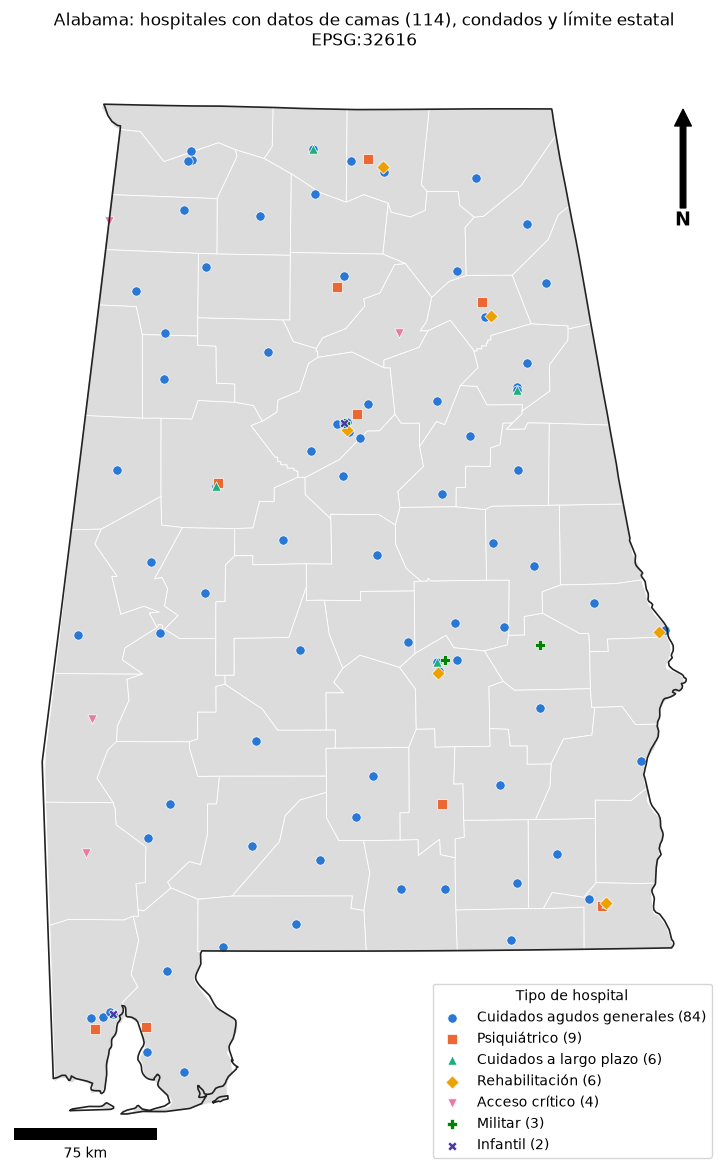

In [8]:
tipos_orden = hosp_p["tipo"].value_counts().index.tolist()
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
fig, ax = plt.subplots(figsize=(10, 12))
cty_p.plot(ax=ax, color="#dcdcdc", edgecolor="white", linewidth=0.6)
for i, t in enumerate(tipos_orden):
    sub = hosp_p[hosp_p["tipo"] == t]
    sub.plot(ax=ax, color=CAT[i], marker=markers[i], markersize=45, edgecolor="white", linewidth=0.5,
             label=f"{TIPO_ES.get(t, t)} ({len(sub)})", zorder=3)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.2, zorder=4)
ax.legend(title="Tipo de hospital", loc="lower right", frameon=True)
add_north_and_scale(ax)
ax.set_title(f"{STATE_NAME}: hospitales con datos de camas ({len(hosp_p)}), condados y límite estatal\n"
             f"{CRS_PROJ}", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Task 1.2

Estadísticas por condado $k$ (hospitales asignados por intersección espacial punto-en-polígono):
* $n_k$ hospitales, $B_k = \sum_{j\in k}$ camas totales, $B^{UCI}_k = \sum_{j\in k}$ camas UCI (UCI nula → 0),
  $P_k$ población.
* Camas por 10,000 hab.: $b_k = 10^4\,B_k / P_k$; camas UCI por 10,000 hab.: $b^{UCI}_k = 10^4\,B^{UCI}_k / P_k$.
* Condados sin hospitales: 0 en todas las columnas numéricas.

In [9]:
hj = gpd.sjoin(hosp_p, cty_p[["fips", "geometry"]], how="left", predicate="within")
print(f"Hospitales asignados a un condado: {hj['fips'].notna().sum()} de {len(hj)} | "
      f"coinciden con la columna fips_condado: {(hj['fips'] == hj['fips_condado']).mean():.1%}")

agg = hj.groupby("fips").agg(hospitales=("nombre", "size"), camas_total=("camas_total", "sum"),
                             camas_uci=("camas_icu", lambda s: s.fillna(0).sum()))
stats_cty = cty_p[["fips", "nombre", "poblacion", "area_km2"]].merge(agg, on="fips", how="left")
stats_cty[["hospitales", "camas_total", "camas_uci"]] = stats_cty[["hospitales", "camas_total", "camas_uci"]].fillna(0)
stats_cty["hospitales"] = stats_cty["hospitales"].astype(int)
stats_cty["camas_10k"] = 1e4 * stats_cty["camas_total"] / stats_cty["poblacion"]
stats_cty["uci_10k"] = 1e4 * stats_cty["camas_uci"] / stats_cty["poblacion"]
tabla_12 = stats_cty.drop(columns="area_km2").sort_values("nombre").reset_index(drop=True)
tabla_12.index += 1
print(f"Condados sin hospital: {(stats_cty.hospitales == 0).sum()} de {len(stats_cty)}")
tabla_12

Hospitales asignados a un condado: 114 de 114 | coinciden con la columna fips_condado: 98.2%
Condados sin hospital: 9 de 67


,fips,nombre,poblacion,hospitales,camas_total,camas_uci,camas_10k,uci_10k
1,01001,Autauga,"55,869.00",1,55.00,6.00,9.84,1.07
2,01003,Baldwin,"223,234.00",4,362.00,51.00,16.22,2.28
3,01005,Barbour,"24,686.00",1,30.00,5.00,12.15,2.03
4,01007,Bibb,"22,394.00",1,25.00,0.00,11.16,0.00
5,01009,Blount,"57,826.00",1,25.00,6.00,4.32,1.04
6,01011,Bullock,"10,101.00",1,30.00,0.00,29.70,0.00
7,01013,Butler,"19,448.00",2,66.00,7.00,33.94,3.60
8,01015,Calhoun,"113,605.00",4,446.00,24.00,39.26,2.11
9,01017,Chambers,"33,254.00",0,0.00,0.00,0.00,0.00
10,01019,Cherokee,"26,196.00",1,45.00,0.00,17.18,0.00


### a. Cinco condados con menos camas por habitante (población > 10,000)
Varios condados tienen 0 camas; en caso de empate se ordena por población descendente (más personas sin camas
locales = mayor vulnerabilidad).

In [10]:
big = stats_cty[stats_cty["poblacion"] > 10_000]
print(f"Condados con > 10,000 hab.: {len(big)} | de ellos con 0 camas: {(big.camas_total == 0).sum()}")
low5 = big.sort_values(["camas_10k", "poblacion"], ascending=[True, False]).head(5).reset_index(drop=True)
low5.index += 1
low5[["nombre", "poblacion", "hospitales", "camas_total", "camas_uci", "camas_10k", "uci_10k"]]

Condados con > 10,000 hab.: 64 | de ellos con 0 camas: 7


,nombre,poblacion,hospitales,camas_total,camas_uci,camas_10k,uci_10k
1,Russell,"57,961.00",0,0.00,0.00,0.00,0.00
2,Chambers,"33,254.00",0,0.00,0.00,0.00,0.00
3,Randolph,"22,722.00",0,0.00,0.00,0.00,0.00
4,Henry,"17,205.00",0,0.00,0.00,0.00,0.00
5,Cleburne,"14,910.00",0,0.00,0.00,0.00,0.00


### b. Cinco condados con mayor concentración de camas
Para evaluar si la concentración es un efecto de **hospitales regionales**, se recalcula la razón de camas
incluyendo la población de los condados vecinos (que comparten frontera):
$b^{reg}_k = 10^4 \,(B_k + \sum_{l \in V(k)} B_l) / (P_k + \sum_{l\in V(k)} P_l)$.

In [11]:
top5c = stats_cty.sort_values("camas_10k", ascending=False).head(5).copy()
geo_idx = cty_p.set_index("fips").geometry
rows = []
for _, r in top5c.iterrows():
    neigh = cty_p[cty_p.geometry.touches(geo_idx[r.fips])]["fips"]
    nb = stats_cty[stats_cty["fips"].isin(neigh)]
    big_h = hosp_p[hosp_p["fips_condado"] == r.fips].sort_values("camas_total", ascending=False).iloc[0]
    rows.append({"condado": r.nombre, "poblacion": r.poblacion, "camas_total": r.camas_total,
                 "camas_10k": r.camas_10k, "vecinos": len(nb), "vecinos_sin_hospital": int((nb.hospitales == 0).sum()),
                 "camas_10k_vecinos": 1e4 * nb.camas_total.sum() / nb.poblacion.sum(),
                 "camas_10k_regional": 1e4 * (r.camas_total + nb.camas_total.sum()) / (r.poblacion + nb.poblacion.sum()),
                 "hospital_principal": f"{big_h.nombre.title()} ({big_h.camas_total:.0f} camas)"})
top5_tbl = pd.DataFrame(rows)
top5_tbl.index += 1
print(f"Promedio estatal: {1e4 * stats_cty.camas_total.sum() / stats_cty.poblacion.sum():.1f} camas por 10,000 hab.")
with pd.option_context("display.max_colwidth", 60):
    display(top5_tbl)

Promedio estatal: 30.4 camas por 10,000 hab.


,condado,poblacion,camas_total,camas_10k,vecinos,vecinos_sin_hospital,camas_10k_vecinos,camas_10k_regional,hospital_principal
1,Macon,"18,068.00",143.00,79.15,6,1,29.83,31.32,Central Alabama Veterans Health Care System East Campus ...
2,Houston,"105,882.00",651.00,61.48,3,1,16.19,40.35,Southeast Alabama Medical Center (327 camas)
3,Etowah,"102,268.00",590.00,57.69,6,0,18.82,25.95,Riverview Regional Medical Center (256 camas)
4,Jefferson,"658,573.00","3,696.00",56.12,6,0,16.08,36.08,University Of Alabama Hospital (1063 camas)
5,Colbert,"55,241.00",300.00,54.31,3,0,22.29,30.62,Helen Keller Memorial Hospital (178 camas)


### c. Distribuciones: camas por hospital y camas por habitante por condado
Se reporta la asimetría muestral (coeficiente de Fisher–Pearson, $g_1 = m_3 / m_2^{3/2}$) y la comparación
media vs. mediana.

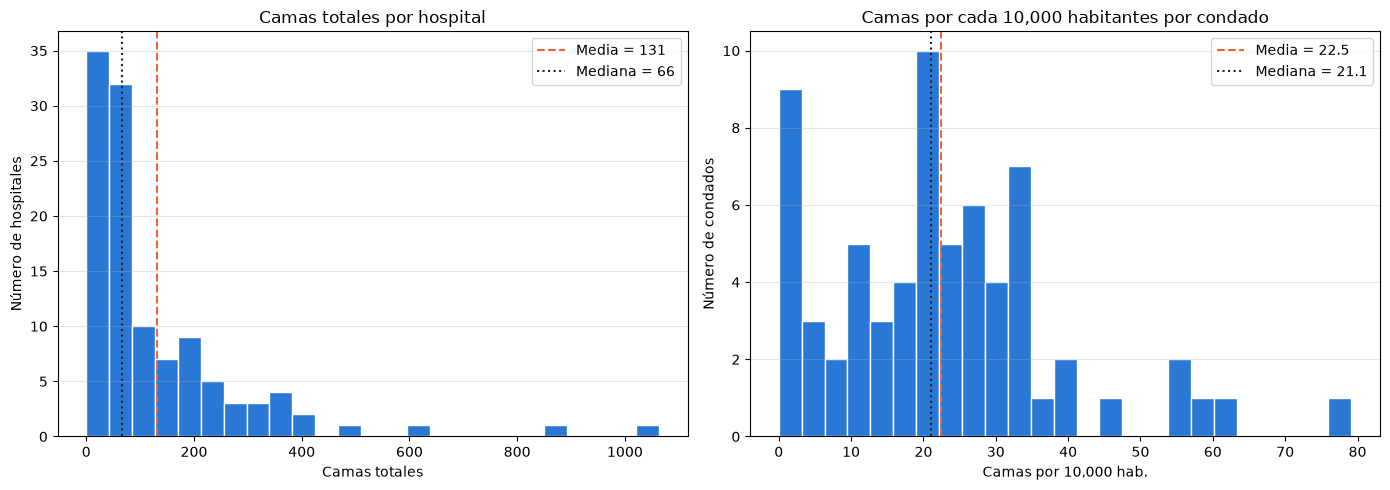

Condados con 0 camas: 9 de 67


,camas por hospital,camas por 10k hab. (condado)
n,114.00,67.00
media,130.73,22.45
mediana,65.50,21.06
mínimo,0.00,0.00
máximo,"1,063.00",79.15
asimetría g1,3.03,0.91
valores extremos (> Q3 + 1.5·IQR),6.00,2.00


In [12]:
camas_h = hosp_p["camas_total"]
camas_c = stats_cty["camas_10k"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.hist(camas_h, bins=25, color=CAT[0], edgecolor="white")
a1.axvline(camas_h.mean(), color=CAT[1], ls="--", lw=1.5, label=f"Media = {camas_h.mean():.0f}")
a1.axvline(camas_h.median(), color="#222222", ls=":", lw=1.5, label=f"Mediana = {camas_h.median():.0f}")
a1.set(title="Camas totales por hospital", xlabel="Camas totales", ylabel="Número de hospitales")
a1.legend()
a1.grid(alpha=0.3, axis="y")
a2.hist(camas_c, bins=25, color=CAT[0], edgecolor="white")
a2.axvline(camas_c.mean(), color=CAT[1], ls="--", lw=1.5, label=f"Media = {camas_c.mean():.1f}")
a2.axvline(camas_c.median(), color="#222222", ls=":", lw=1.5, label=f"Mediana = {camas_c.median():.1f}")
a2.set(title="Camas por cada 10,000 habitantes por condado", xlabel="Camas por 10,000 hab.",
       ylabel="Número de condados")
a2.legend()
a2.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

desc = pd.DataFrame({
    "camas por hospital": [len(camas_h), camas_h.mean(), camas_h.median(), camas_h.min(), camas_h.max(),
                           stats.skew(camas_h), (camas_h > camas_h.quantile(0.75) + 1.5 * stats.iqr(camas_h)).sum()],
    "camas por 10k hab. (condado)": [len(camas_c), camas_c.mean(), camas_c.median(), camas_c.min(), camas_c.max(),
                                    stats.skew(camas_c), (camas_c > camas_c.quantile(0.75) + 1.5 * stats.iqr(camas_c)).sum()]},
    index=["n", "media", "mediana", "mínimo", "máximo", "asimetría g1", "valores extremos (> Q3 + 1.5·IQR)"])
print(f"Condados con 0 camas: {(camas_c == 0).sum()} de {len(camas_c)}")
desc

## Task 1.3

### a. Buffers de 10, 25 y 50 km y unión

Para cada radio $r$: $C_r = \bigcup_j B_r(s_j)$, donde $B_r(s_j) = \{x : \lVert x - s_j \rVert \le r\}$ es el
buffer del hospital $j$. Se usa `unary_union` para eliminar el doble conteo donde los buffers se traslapan.

In [13]:
from shapely.ops import unary_union

coverage = {}
for r in RADII_KM:
    buffers = hosp_p.geometry.buffer(r * 1000, quad_segs=32)        # metros, porque el CRS es UTM
    coverage[r] = unary_union(buffers.values)
    a_in = coverage[r].intersection(state_poly).area / 1e6
    print(f"r = {r:>2} km: {len(buffers)} buffers -> 1 polígono ({coverage[r].geom_type}), área cubierta dentro "
          f"del estado = {a_in:,.0f} km² ({100 * a_in / (state_poly.area / 1e6):.1f} %)")

r = 10 km: 114 buffers -> 1 polígono (MultiPolygon), área cubierta dentro del estado = 24,146 km² (18.1 %)
r = 25 km: 114 buffers -> 1 polígono (MultiPolygon), área cubierta dentro del estado = 103,421 km² (77.3 %)


r = 50 km: 114 buffers -> 1 polígono (Polygon), área cubierta dentro del estado = 133,562 km² (99.9 %)


### b. Población cubierta por radio (supuesto de densidad uniforme)

Si la población del condado $k$ está distribuida uniformemente sobre su área $A_k$, la población cubierta es
proporcional al área cubierta:
$$P^{cub}_r = \sum_k P_k\,\frac{\lvert A_k \cap C_r\rvert}{\lvert A_k\rvert}, \qquad \text{Cob}(r) = \frac{P^{cub}_r}{\sum_k P_k}.$$

In [14]:
P_TOTAL = cty_p["poblacion"].sum()


def frac_covered(cov_geom):
    """Fracción del área de cada condado dentro del polígono de cobertura."""
    return (cty_p.geometry.intersection(cov_geom).area / cty_p.area).clip(0, 1).values


cov_rows = []
for r in RADII_KM:
    pc = (cty_p["poblacion"] * frac_covered(coverage[r])).sum()
    cov_rows.append({"radio_km": r, "poblacion_cubierta_estimada": pc, "poblacion_total": P_TOTAL,
                     "pct_cobertura": 100 * pc / P_TOTAL})
cov_tbl = pd.DataFrame(cov_rows)
cov_tbl

,radio_km,poblacion_cubierta_estimada,poblacion_total,pct_cobertura
0,10,"1,154,006.70","4,903,185.00",23.54
1,25,"3,975,745.68","4,903,185.00",81.08
2,50,"4,899,800.84","4,903,185.00",99.93


### c. Mapa de cobertura con radio de 25 km

Cada condado se clasifica según la fracción de su área dentro de $C_{25}$: completamente cubierto (≥ 99.5 %),
parcialmente cubierto, o no cubierto (< 0.5 %). Escala divergente rojo ↔ azul con gris neutro al centro: el rojo
resalta las zonas sin cobertura.

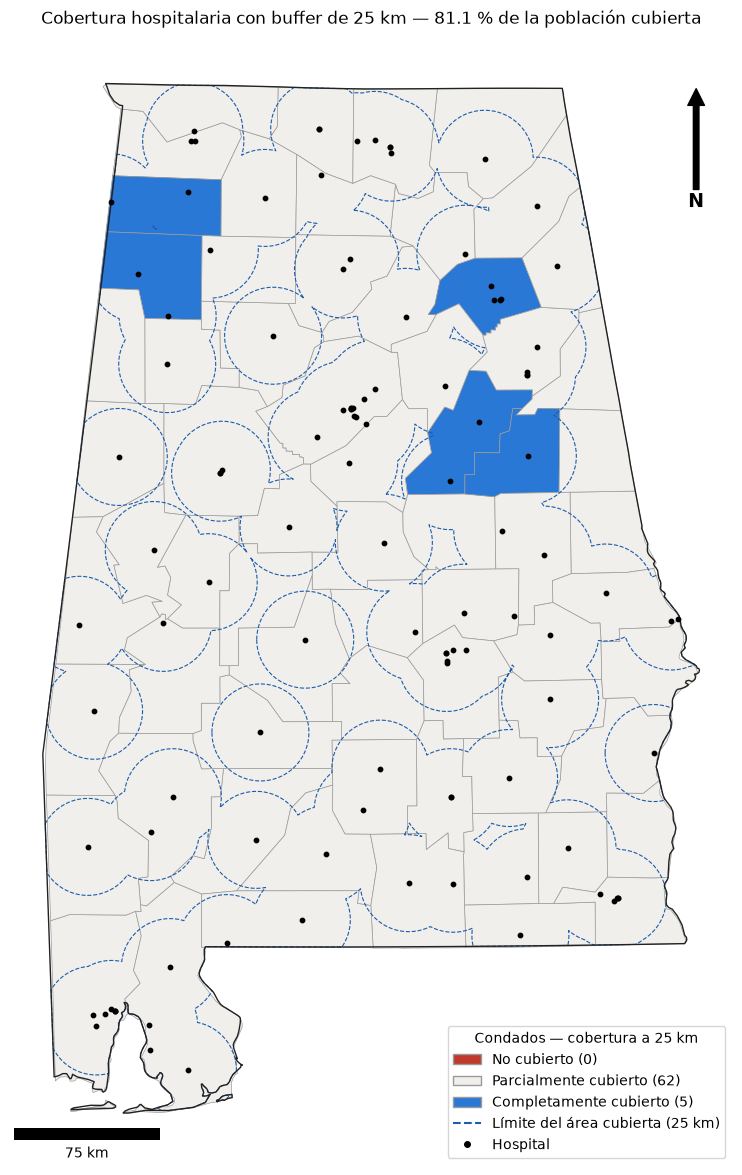

                        condados
cobertura25                     
Parcialmente cubierto         62
Completamente cubierto         5
No cubierto                    0

Condados NO cubiertos: ninguno


In [15]:
cov25 = coverage[R_MAP]
cty_p["frac_cub25"] = frac_covered(cov25)
cty_p["cobertura25"] = pd.cut(cty_p["frac_cub25"], [-0.01, 0.005, 0.995, 1.01],
                              labels=["No cubierto", "Parcialmente cubierto", "Completamente cubierto"])
DIV = {"No cubierto": "#c0392b", "Parcialmente cubierto": NEUTRAL, "Completamente cubierto": "#2a78d6"}

fig, ax = plt.subplots(figsize=(10, 12))
cty_p.plot(ax=ax, color=cty_p["cobertura25"].map(DIV).astype(str), edgecolor="#9a9a9a", linewidth=0.5)
gpd.GeoSeries([cov25.intersection(state_poly)], crs=CRS_PROJ).boundary.plot(ax=ax, color="#1c5cab",
                                                                             linewidth=0.8, linestyle="--")
hosp_p.plot(ax=ax, color="black", markersize=10, zorder=4)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.0)
counts = cty_p["cobertura25"].value_counts()
handles = [Patch(facecolor=c, edgecolor="#9a9a9a", label=f"{k} ({counts.get(k, 0)})") for k, c in DIV.items()]
handles += [Line2D([], [], color="#1c5cab", ls="--", label=f"Límite del área cubierta ({R_MAP} km)"),
            Line2D([], [], marker="o", color="black", ls="", markersize=4, label="Hospital")]
ax.legend(handles=handles, loc="lower right", title=f"Condados — cobertura a {R_MAP} km")
add_north_and_scale(ax)
ax.set_title(f"Cobertura hospitalaria con buffer de {R_MAP} km — "
             f"{cov_tbl.loc[cov_tbl.radio_km == R_MAP, 'pct_cobertura'].item():.1f} % de la población cubierta")
ax.set_axis_off()
plt.tight_layout()
plt.show()
print(counts.to_frame("condados"))
print("\nCondados NO cubiertos:", ", ".join(cty_p.loc[cty_p.cobertura25 == "No cubierto", "nombre"]) or "ninguno")

# Task 2
## Task 2.1

### a. Distancia del centroide de cada condado al hospital más cercano
$d_k = \min_j \lVert c_k - s_j \rVert$, con $c_k$ el centroide del condado en el CRS proyectado (metros); el
mínimo se calcula con un árbol k-d.

In [16]:
hosp_xy = np.column_stack([hosp_p.geometry.x, hosp_p.geometry.y])
tree = cKDTree(hosp_xy)
cent = cty_p.geometry.centroid
d, j = tree.query(np.column_stack([cent.x, cent.y]))
cty_p["dist_km"] = d / 1000
cty_p["hosp_cercano"] = hosp_p["nombre"].str.title().values[j]
cty_p["tipo_cercano"] = hosp_p["tipo"].values[j]
cty_p["camas_cercano"] = hosp_p["camas_total"].values[j]

far10 = cty_p.sort_values("dist_km", ascending=False).head(10)
far10_tbl = far10[["nombre", "poblacion", "dist_km", "hosp_cercano"]].reset_index(drop=True)
far10_tbl.index += 1
print(f"Distancia media centroide–hospital: {cty_p.dist_km.mean():.1f} km (mediana {cty_p.dist_km.median():.1f} km)")
far10_tbl

Distancia media centroide–hospital: 12.1 km (mediana 9.1 km)


,nombre,poblacion,dist_km,hosp_cercano
1,Lowndes,"9,726.00",36.63,L. V. Stabler Memorial Hospital
2,Henry,"17,205.00",34.51,Healthsouth Rehabilitation Hospital
3,Randolph,"22,722.00",34.01,Clay County Hospital
4,Chambers,"33,254.00",30.31,East Alabama Medical Center
5,Marengo,"18,863.00",28.91,Bryan W. Whitfield Memorial Hospital
6,Perry,"8,923.00",27.73,Hale County Hospital
7,Russell,"57,961.00",27.03,Regional Rehabilitation Hospital
8,Lamar,"13,805.00",26.47,Fayette Medical Center
9,Cleburne,"14,910.00",26.22,Rmc Jacksonville
10,Coosa,"10,663.00",25.58,Coosa Valley Medical Center


**Verificación del efecto de borde.** El enunciado restringe los hospitales al estado, pero varios condados
alejados colindan con Georgia o Mississippi. Como referencia (no se usa en el resto del análisis), se recalcula la
distancia incluyendo los hospitales con camas de **todos** los estados.

In [17]:
hosp_all_p = hosp.to_crs(CRS_PROJ)
d_all, j_all = cKDTree(np.column_stack([hosp_all_p.geometry.x, hosp_all_p.geometry.y])).query(
    np.column_stack([cent.x, cent.y]))
cty_p["dist_km_todos"] = d_all / 1000
cty_p["estado_cercano_todos"] = hosp_all_p["estado"].values[j_all]
borde = cty_p.loc[far10.index, ["nombre", "dist_km", "dist_km_todos", "estado_cercano_todos"]].reset_index(drop=True)
borde.index += 1
borde

,nombre,dist_km,dist_km_todos,estado_cercano_todos
1,Lowndes,36.63,36.63,AL
2,Henry,34.51,31.84,GA
3,Randolph,34.01,34.01,AL
4,Chambers,30.31,30.31,AL
5,Marengo,28.91,28.91,AL
6,Perry,27.73,27.73,AL
7,Russell,27.03,27.03,AL
8,Lamar,26.47,26.47,AL
9,Cleburne,26.22,26.22,AL
10,Coosa,25.58,25.58,AL


### b. Curva de cobertura acumulada (5–100 km)

$\text{Cob}(r) = \sum_k P_k\,\lvert A_k\cap C_r\rvert/\lvert A_k\rvert \,/\, P$ para $r = 5, 10, \dots, 100$ km.

**Punto de inflexión.** La curva es cóncava, así que el punto relevante es el *codo* (rendimientos
decrecientes). Se identifica con el método **Kneedle**: con ambos ejes normalizados a [0, 1], el codo maximiza
la distancia vertical entre la curva y la recta que une sus extremos, $r^{knee} = \arg\max_r[\tilde C(r) - \tilde r]$.
Como criterio complementario se reporta el primer radio en que la ganancia marginal cae bajo 1 p.p. por cada 5 km.

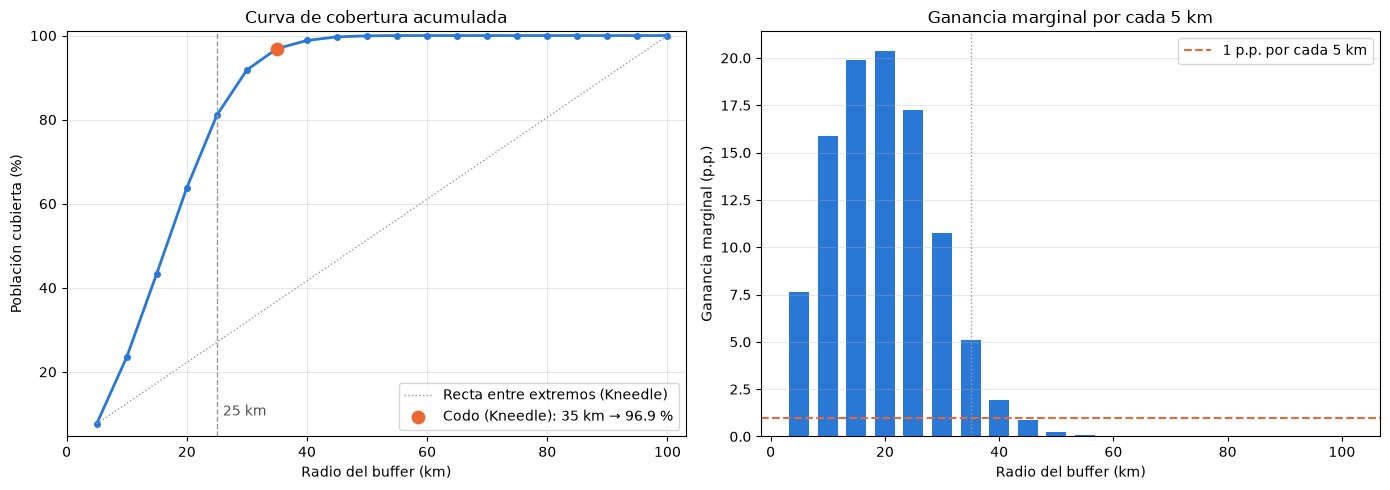

Codo (Kneedle): r = 35 km, cobertura = 96.9 %
Primer radio con ganancia < 1 p.p.: r = 45 km, cobertura = 99.7 %


radio_km,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100
pct_cobertura,7.60,23.50,43.40,63.80,81.00,91.80,96.90,98.80,99.70,99.90,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
ganancia_pp,7.60,15.90,19.90,20.40,17.30,10.80,5.10,1.90,0.90,0.20,0.10,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
radii = np.arange(5, 101, 5)
curve = np.array([100 * (cty_p["poblacion"] * frac_covered(unary_union(hosp_p.geometry.buffer(r * 1000).values))).sum()
                  / P_TOTAL for r in radii])
marg = np.diff(np.concatenate([[0], curve]))

xn = (radii - radii.min()) / (radii.max() - radii.min())
yn = (curve - curve.min()) / (curve.max() - curve.min())
r_knee = radii[np.argmax(yn - xn)]
c_knee = curve[radii == r_knee].item()
r_1pp = radii[np.argmax(marg < 1)]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.plot(radii, curve, color=CAT[0], lw=2, marker="o", markersize=4)
a1.plot([radii[0], radii[-1]], [curve[0], curve[-1]], color="#9a9a9a", lw=1, ls=":", label="Recta entre extremos (Kneedle)")
a1.scatter([r_knee], [c_knee], color=CAT[1], s=80, zorder=3, label=f"Codo (Kneedle): {r_knee} km → {c_knee:.1f} %")
a1.axvline(R_MAP, color="#9a9a9a", lw=1, ls="--")
a1.text(R_MAP + 1, curve.min() + 2, f"{R_MAP} km", color="#52514e")
a1.set(xlabel="Radio del buffer (km)", ylabel="Población cubierta (%)", title="Curva de cobertura acumulada",
       xlim=(0, 103), ylim=(curve.min() - 3, 101))
a1.grid(alpha=0.3)
a1.legend(loc="lower right")
a2.bar(radii, marg, color=CAT[0], width=3.5)
a2.axhline(1, color=CAT[1], lw=1.5, ls="--", label="1 p.p. por cada 5 km")
a2.axvline(r_knee, color="#9a9a9a", lw=1, ls=":")
a2.set(xlabel="Radio del buffer (km)", ylabel="Ganancia marginal (p.p.)", title="Ganancia marginal por cada 5 km")
a2.grid(alpha=0.3, axis="y")
a2.legend()
plt.tight_layout()
plt.show()

print(f"Codo (Kneedle): r = {r_knee} km, cobertura = {c_knee:.1f} %")
print(f"Primer radio con ganancia < 1 p.p.: r = {r_1pp} km, cobertura = {curve[radii == r_1pp].item():.1f} %")
pd.DataFrame({"radio_km": radii, "pct_cobertura": curve, "ganancia_pp": marg}).set_index("radio_km").T.round(1)

### c. Tipo y capacidad del hospital más cercano a los cinco condados más alejados
Para responder si los condados alejados quedan cerca de hospitales de menor capacidad, se compara con todos los
condados y se calcula la correlación de rangos de Spearman entre $d_k$ y las camas del hospital más cercano.

In [19]:
far5 = far10.head(5)
far5_tbl = far5[["nombre", "dist_km", "hosp_cercano", "tipo_cercano", "camas_cercano"]].reset_index(drop=True)
far5_tbl["tipo_cercano"] = far5_tbl["tipo_cercano"].map(TIPO_ES)
far5_tbl.index += 1
display(far5_tbl)

rho, pval = stats.spearmanr(cty_p["dist_km"], cty_p["camas_cercano"])
comp = pd.DataFrame({
    "5 condados más alejados": [far5.camas_cercano.median(), far5.camas_cercano.mean(), (far5.camas_cercano < 50).mean() * 100],
    "resto de condados": [cty_p.drop(far5.index).camas_cercano.median(), cty_p.drop(far5.index).camas_cercano.mean(),
                          (cty_p.drop(far5.index).camas_cercano < 50).mean() * 100],
    "todos los hospitales": [hosp_p.camas_total.median(), hosp_p.camas_total.mean(), (hosp_p.camas_total < 50).mean() * 100]},
    index=["mediana de camas", "media de camas", "% con < 50 camas"])
print(f"Correlación de Spearman (distancia vs camas del hospital más cercano): rho = {rho:.2f}, p = {pval:.3f}")
comp

,nombre,dist_km,hosp_cercano,tipo_cercano,camas_cercano
1,Lowndes,36.63,L. V. Stabler Memorial Hospital,Cuidados agudos generales,44.00
2,Henry,34.51,Healthsouth Rehabilitation Hospital,Rehabilitación,51.00
3,Randolph,34.01,Clay County Hospital,Cuidados agudos generales,46.00
4,Chambers,30.31,East Alabama Medical Center,Cuidados agudos generales,372.00
5,Marengo,28.91,Bryan W. Whitfield Memorial Hospital,Cuidados agudos generales,37.00


Correlación de Spearman (distancia vs camas del hospital más cercano): rho = 0.20, p = 0.102


,5 condados más alejados,resto de condados,todos los hospitales
mediana de camas,46.00,46.00,65.50
media de camas,110.00,94.13,130.73
% con < 50 camas,60.00,58.06,43.86


## Task 2.2

| Componente | Variable cruda por condado $k$ | Dirección |
|---|---|---|
| $C_1$ distancia | $d_k$ — distancia del centroide al hospital más cercano (km) | más = más vulnerable |
| $C_2$ inverso de camas per cápita | $P_k / B_k$ — habitantes por cama; sin hospitales → máximo observado | más = más vulnerable |
| $C_3$ ocupación | $\bar o_k$ — ocupación promedio de los hospitales a ≤ 50 km del centroide; ninguno → máximo | más = más vulnerable |

### a. Normalización min-max
$\tilde x_k = \dfrac{x_k - \min_l x_l}{\max_l x_l - \min_l x_l} \in [0,1]$.

In [20]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())


vul = cty_p[["fips", "nombre", "poblacion", "geometry"]].merge(stats_cty[["fips", "camas_total", "hospitales"]], on="fips")
vul["x1_dist_km"] = cty_p["dist_km"].values

# C2: inverso de camas por habitante (habitantes por cama); condados sin camas -> valor máximo observado
inv = vul["poblacion"] / vul["camas_total"].replace(0, np.nan)
vul["x2_hab_por_cama"] = inv.fillna(inv.max())

# C3: ocupación promedio de hospitales dentro de 50 km del centroide; sin hospitales cercanos -> máximo
occ = hosp_p["ocupacion_total"].values
near50 = tree.query_ball_point(np.column_stack([cent.x, cent.y]), r=50_000)
occ_mean = np.array([np.nanmean(occ[m]) if len(m) and np.isfinite(occ[m]).any() else np.nan for m in near50])
vul["n_hosp_50km"] = [len(m) for m in near50]
vul["x3_ocupacion_50km"] = np.where(np.isnan(occ_mean), np.nanmax(occ_mean), occ_mean)

vul["C1"] = minmax(vul["x1_dist_km"])
vul["C2"] = minmax(vul["x2_hab_por_cama"])
vul["C3"] = minmax(vul["x3_ocupacion_50km"])
print(f"Condados sin camas (C2 = máximo): {(vul.camas_total == 0).sum()} | "
      f"sin hospitales a ≤ 50 km (C3 = máximo): {np.isnan(occ_mean).sum()}")
vul[["x1_dist_km", "x2_hab_por_cama", "x3_ocupacion_50km", "C1", "C2", "C3"]].describe().T[["mean", "50%", "min", "max"]]

Condados sin camas (C2 = máximo): 9 | sin hospitales a ≤ 50 km (C3 = máximo): 0


,mean,50%,min,max
x1_dist_km,12.15,9.09,0.53,36.63
x2_hab_por_cama,792.34,474.90,126.35,"2,313.04"
x3_ocupacion_50km,0.39,0.39,0.07,0.71
C1,0.32,0.24,0.00,1.00
C2,0.30,0.16,0.00,1.00
C3,0.50,0.50,0.00,1.00


### b. Pesos del índice

$V_k = w_1 C_{1,k} + w_2 C_{2,k} + w_3 C_{3,k}$, con $w_1 + w_2 + w_3 = 1$ (la justificación de cada peso está en el reporte).

In [21]:
WEIGHTS = {"C1": 0.45, "C2": 0.35, "C3": 0.20}
vul["V"] = sum(w * vul[c] for c, w in WEIGHTS.items())

LABELS = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
vul["V_cat"] = pd.qcut(vul["V"], 5, labels=LABELS)
top10 = vul.sort_values("V", ascending=False).head(10)
top10_tbl = top10[["nombre", "poblacion", "x1_dist_km", "x2_hab_por_cama", "x3_ocupacion_50km",
                   "C1", "C2", "C3", "V"]].reset_index(drop=True)
top10_tbl.index += 1
top10_tbl

,nombre,poblacion,x1_dist_km,x2_hab_por_cama,x3_ocupacion_50km,C1,C2,C3,V
1,Lowndes,"9,726.00",36.63,"2,313.04",0.55,1.00,1.00,0.75,0.95
2,Henry,"17,205.00",34.51,"2,313.04",0.53,0.94,1.00,0.71,0.92
3,Russell,"57,961.00",27.03,"2,313.04",0.58,0.73,1.00,0.80,0.84
4,Randolph,"22,722.00",34.01,"2,313.04",0.29,0.93,1.00,0.34,0.84
5,Chambers,"33,254.00",30.31,"2,313.04",0.33,0.82,1.00,0.40,0.80
6,Cleburne,"14,910.00",26.22,"2,313.04",0.44,0.71,1.00,0.58,0.79
7,Perry,"8,923.00",27.73,"2,313.04",0.35,0.75,1.00,0.44,0.78
8,Coosa,"10,663.00",25.58,"2,313.04",0.32,0.69,1.00,0.39,0.74
9,Lamar,"13,805.00",26.47,"2,313.04",0.23,0.72,1.00,0.25,0.72
10,St. Clair,"89,512.00",13.01,"2,237.80",0.55,0.35,0.97,0.75,0.64


### c. Mapa coroplético por quintiles con los 10 condados más vulnerables

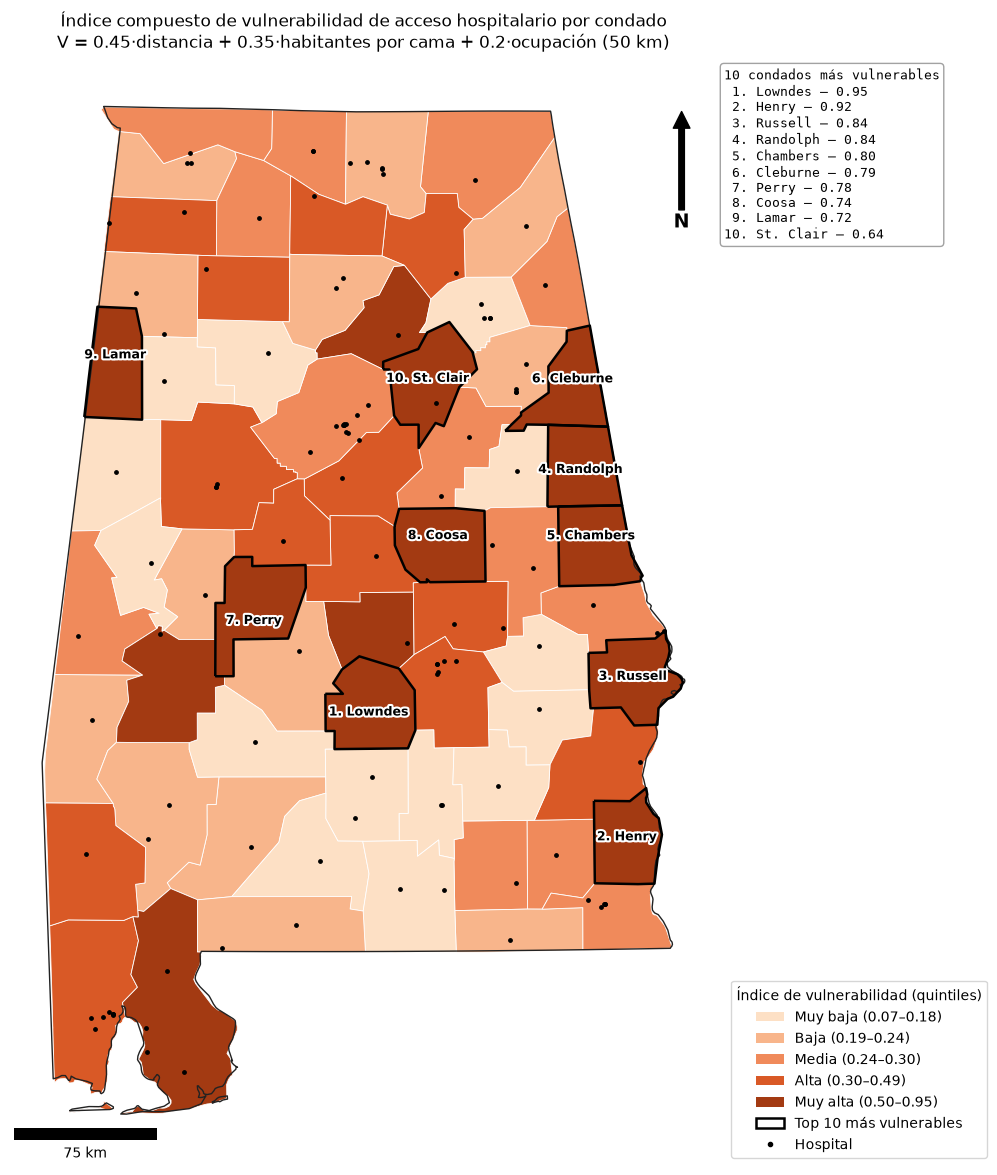

In [22]:
SEQ = ["#fde0c5", "#f8b58b", "#f08a5b", "#d95926", "#a33a12"]   # un solo tono (naranja), claro -> oscuro
fig, ax = plt.subplots(figsize=(11, 12))
vul.plot(ax=ax, color=vul["V_cat"].map(dict(zip(LABELS, SEQ))).astype(str), edgecolor="white", linewidth=0.6)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.0)
top10.boundary.plot(ax=ax, color="black", linewidth=1.8)
hosp_p.plot(ax=ax, color="black", markersize=6, zorder=4)
names = []
for rank, (_, r) in enumerate(top10.iterrows(), start=1):
    pt = r.geometry.representative_point()
    ax.annotate(f"{rank}. {r.nombre}", xy=(pt.x, pt.y), fontsize=9, fontweight="bold", ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")], zorder=5)
    names.append(f"{rank:>2}. {r.nombre} — {r.V:.2f}")
ax.text(1.01, 0.99, "10 condados más vulnerables\n" + "\n".join(names), transform=ax.transAxes,
        va="top", ha="left", fontsize=9, family="monospace",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#9a9a9a", alpha=0.92))
bins = vul.groupby("V_cat", observed=True)["V"].agg(["min", "max"])
handles = [Patch(facecolor=c, label=f"{l} ({bins.loc[l, 'min']:.2f}–{bins.loc[l, 'max']:.2f})")
           for l, c in zip(LABELS, SEQ)]
handles += [Patch(facecolor="none", edgecolor="black", linewidth=1.8, label="Top 10 más vulnerables"),
            Line2D([], [], marker="o", color="black", ls="", markersize=3, label="Hospital")]
ax.legend(handles=handles, title="Índice de vulnerabilidad (quintiles)", loc="lower left", bbox_to_anchor=(1.01, 0))
add_north_and_scale(ax)
ax.set_title("Índice compuesto de vulnerabilidad de acceso hospitalario por condado\n"
             f"V = {WEIGHTS['C1']}·distancia + {WEIGHTS['C2']}·habitantes por cama + {WEIGHTS['C3']}·ocupación (50 km)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Task 2.3

**Formulación MCLP (Church & ReVelle, 1974)** adaptada a la cobertura existente:

$$\max \sum_{i} a_i\, y_i \quad \text{s.a.}\quad y_i \le \sum_{j \in N_i} x_j,\qquad \sum_j x_j = p,\qquad x_j, y_i \in \{0,1\}$$

donde la demanda $a_i$ es la población **sin cobertura actual** (densidad uniforme por condado), $j$ los puntos
candidatos, $N_i$ los candidatos a ≤ $S = 25$ km de la demanda $i$, y $p = 3$ nuevos hospitales.

### a. Grilla de candidatos (50 km)
Se generan puntos cada 50 km sobre la extensión del estado y se eliminan los que caen fuera del límite estatal
(intersección espacial con el polígono de `estados_eeuu.geojson`).

In [23]:
SPACING, S, P_NEW = 50_000, R_MAP * 1000, 3
minx, miny, maxx, maxy = state_poly.bounds
gx, gy = np.meshgrid(np.arange(minx + SPACING / 2, maxx, SPACING), np.arange(miny + SPACING / 2, maxy, SPACING))
grid = gpd.GeoDataFrame(geometry=gpd.points_from_xy(gx.ravel(), gy.ravel()), crs=CRS_PROJ)
cand = grid[grid.intersects(state_poly)].reset_index(drop=True)
print(f"Puntos de la grilla: {len(grid)} | fuera del estado: {len(grid) - len(cand)} | candidatos: {len(cand)}")

Puntos de la grilla: 77 | fuera del estado: 22 | candidatos: 55


### b. Población adicional por candidato
Con densidad uniforme $\rho_k = P_k / \lvert A_k\rvert$, la ganancia del candidato $j$ es la población de la parte
**no cubierta** de cada condado que cae dentro de su buffer:
$g_j = \sum_k \rho_k \,\lvert B_S(c_j) \cap (A_k \setminus C_{25})\rvert$.

In [24]:
dens = (cty_p["poblacion"] / cty_p.area).values               # hab/m²
cand_buf = cand.geometry.buffer(S, quad_segs=32)


def gains(cov_geom):
    """Población no cubierta (bajo cov_geom) dentro del buffer de cada candidato."""
    uncovered = cty_p.geometry.difference(cov_geom)          # A_k \ C
    out = np.zeros(len(cand))
    for i, b in enumerate(cand_buf):
        out[i] = (uncovered.intersection(b).area.values * dens).sum()
    return out


cand["pob_adicional"] = gains(cov25)
print(f"Candidatos con ganancia > 1,000 hab.: {(cand.pob_adicional > 1000).sum()} de {len(cand)}")
cand.sort_values("pob_adicional", ascending=False).head(10).assign(
    x=lambda d: d.geometry.x.round(), y=lambda d: d.geometry.y.round()).drop(columns="geometry")

Candidatos con ganancia > 1,000 hab.: 45 de 55


,pob_adicional,x,y
2,"106,236.13","384,450.00","3,418,986.00"
37,"63,110.65","484,450.00","3,718,986.00"
48,"36,884.73","534,450.00","3,818,986.00"
53,"34,698.86","534,450.00","3,868,986.00"
36,"32,412.96","434,450.00","3,718,986.00"
20,"30,828.23","584,450.00","3,568,986.00"
0,"25,848.87","384,450.00","3,368,986.00"
52,"23,420.84","484,450.00","3,868,986.00"
22,"22,047.02","684,450.00","3,568,986.00"
34,"20,225.83","634,450.00","3,668,986.00"


### c. Algoritmo voraz (p = 3)
En cada iteración: (1) elegir $j^* = \arg\max_j g_j$ con la cobertura vigente, (2) marcarlo como seleccionado,
(3) actualizar la cobertura $C \leftarrow C \cup B_S(c_{j^*})$, (4) recalcular $g_j$ y repetir.

In [25]:
cov_state = cov25
base_pct = 100 * (cty_p["poblacion"] * frac_covered(cov_state)).sum() / P_TOTAL
selected = []
for it in range(1, P_NEW + 1):
    g = gains(cov_state)
    g[[s["idx"] for s in selected]] = -1                       # no repetir candidatos
    j_best = int(np.argmax(g))
    cov_state = cov_state.union(cand_buf.iloc[j_best])         # actualizar el mapa de cobertura
    selected.append({"idx": j_best, "iteracion": it, "pob_adicional": g[j_best],
                     "pct_cobertura_acumulada": 100 * (cty_p["poblacion"] * frac_covered(cov_state)).sum() / P_TOTAL})

sel = cand.loc[[s["idx"] for s in selected]].copy()
sel = sel.assign(**pd.DataFrame(selected).set_index("idx"))
sel = gpd.sjoin(sel, cty_p[["nombre", "geometry"]], predicate="within", how="left").drop(columns="index_right")
sel_ll = sel.to_crs("EPSG:4326")
sel["lat"], sel["lon"] = sel_ll.geometry.y.round(4), sel_ll.geometry.x.round(4)
greedy_tbl = sel[["iteracion", "nombre", "lat", "lon", "pob_adicional", "pct_cobertura_acumulada"]].set_index("iteracion")
print(f"Cobertura actual ({R_MAP} km): {base_pct:.2f} %")
print(f"Cobertura con {P_NEW} nuevos hospitales: {greedy_tbl.pct_cobertura_acumulada.iloc[-1]:.2f} % "
      f"(+{greedy_tbl.pct_cobertura_acumulada.iloc[-1] - base_pct:.2f} p.p., "
      f"{greedy_tbl.pob_adicional.sum():,.0f} personas adicionales)")
greedy_tbl

Cobertura actual (25 km): 81.08 %
Cobertura con 3 nuevos hospitales: 85.29 % (+4.21 p.p., 206,232 personas adicionales)


,nombre,lat,lon,pob_adicional,pct_cobertura_acumulada
iteracion,,,,,
1,Mobile,30.90,-88.21,"106,236.13",83.25
2,Jefferson,33.61,-87.17,"63,110.65",84.54
3,Morgan,34.51,-86.62,"36,884.73",85.29


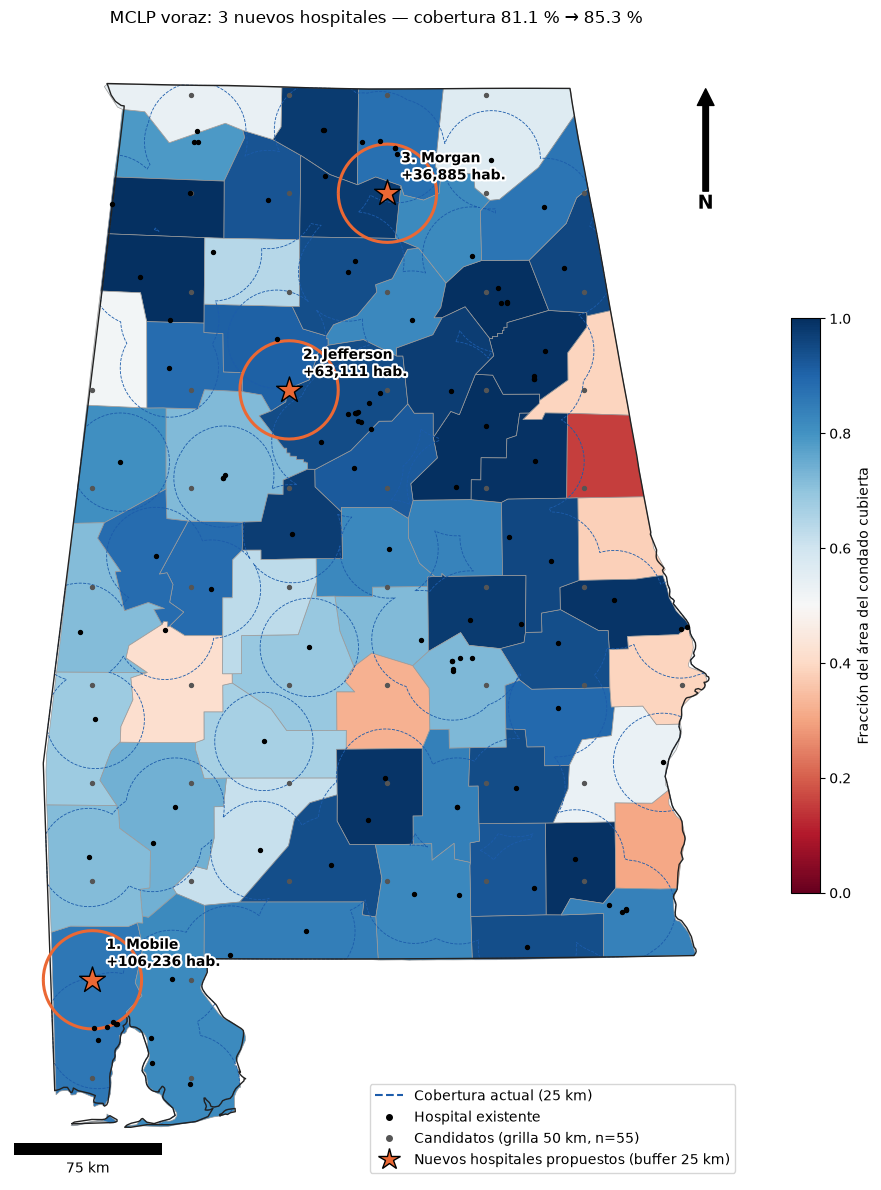

In [26]:
cty_p["frac_final"] = frac_covered(cov_state)
fig, ax = plt.subplots(figsize=(10, 12))
cty_p.plot(ax=ax, column="frac_final", cmap="RdBu", vmin=0, vmax=1, edgecolor="#9a9a9a", linewidth=0.5,
           legend=True, legend_kwds={"label": "Fracción del área del condado cubierta", "shrink": 0.5})
gpd.GeoSeries([cov25.intersection(state_poly)], crs=CRS_PROJ).boundary.plot(ax=ax, color="#1c5cab", lw=0.6, ls="--")
cand.plot(ax=ax, color="#555555", markersize=8, zorder=3)
gpd.GeoSeries(sel.geometry.buffer(S), crs=CRS_PROJ).boundary.plot(ax=ax, color=CAT[1], linewidth=2.2, zorder=4)
hosp_p.plot(ax=ax, color="black", markersize=8, zorder=4)
sel.plot(ax=ax, color=CAT[1], marker="*", markersize=380, edgecolor="black", zorder=5)
for _, r in sel.iterrows():
    ax.annotate(f"{r.iteracion}. {r.nombre}\n+{r.pob_adicional:,.0f} hab.", xy=(r.geometry.x, r.geometry.y),
                xytext=(10, 10), textcoords="offset points", fontsize=10, fontweight="bold",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")], zorder=6)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.0)
ax.legend(handles=[
    Line2D([], [], color="#1c5cab", ls="--", label=f"Cobertura actual ({R_MAP} km)"),
    Line2D([], [], marker="o", color="black", ls="", markersize=4, label="Hospital existente"),
    Line2D([], [], marker="o", color="#555555", ls="", markersize=4, label=f"Candidatos (grilla 50 km, n={len(cand)})"),
    Line2D([], [], marker="*", color=CAT[1], markeredgecolor="black", ls="", markersize=16,
           label=f"Nuevos hospitales propuestos (buffer {R_MAP} km)")], loc="lower right")
add_north_and_scale(ax)
ax.set_title(f"MCLP voraz: {P_NEW} nuevos hospitales — cobertura {base_pct:.1f} % → "
             f"{greedy_tbl.pct_cobertura_acumulada.iloc[-1]:.1f} %")
ax.set_axis_off()
plt.tight_layout()
plt.show()